# Grundkonzepte der Programmierung

### Dietmar Hareter und Fabian Pribahsnik
### 15.03.2026

***

Wir wollen in diesem Notebook nicht nur auf die Grundkonzepte des *tidyverse* eingehen, sondern vor allem nützliche Funktionen aus den Paketen `dplyr`, `tidyr` und `stringr` vorstellen.

Zunächst werden alle benötigten *Pakete* (Erweiterungen) geladen.

In [1]:
# Dateneinlese
library(readxl)      # Ermöglicht das Einlesen von Excel-Dateien (.xls und .xlsx)
library(writexl)     # Das Gegenstück zu readxl. Wird verwendet, um Daten aus R als Excel-Dateien zu exportieren.
library(openxlsx2)   # Ermöglicht das Schreiben und Bearbeiten von Excel-Dateien mit erweiterten Funktionen

# Datenaufbereitung
library(tidyverse)    # Lädt die wichtigsten Pakete des tidyverse

# Generelle Pakete
library(datasets)     # Das Paket `datasets` enthält eine große Anzahl von Datensätzen, die vor allem zum Üben verwendet werden können.


Attache Paket: 'openxlsx2'


Das folgende Objekt ist maskiert 'package:writexl':

    write_xlsx


Das folgende Objekt ist maskiert 'package:readxl':

    read_xlsx


── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter()        masks stats::filter()
✖ dplyr::lag()           masks stats::lag()
✖ openxlsx2::read_xlsx() masks readxl::read_xlsx()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


**Hinweis:** Die Ausgabe der Informationen und das Aufzeigen von Konflikten beim Laden der einzelnen Pakete kann mit den zusätzlichen Parametern `quietly = TRUE` bzw. `warn.conflicts = FALSE` verhindert werden, beispielsweise `library(plotly, quietly = TRUE, warn.conflicts = FALSE)`.

Konflikte entstehen, wenn zwei oder mehrere Pakete eine Funktion mit demselben Namen enthalten. Beispielsweise enthalten die Pakete `dplyr` und `stats` jeweils eine Funktion mit dem Namen `filter()` - siehe die Meldung `dplyr::filter() masks stats::filter()` im Bereich "Conflicts". Bei Aufruf der Funktion `filter()` wird jene Funktion verwendet, die zuletzt geladen wurde. Durch dieses Verhalten von *R* steigt die Fehleranfälligkeit von Programmen. Deshalb wird empfohlen Funktionen, die nicht eindeutig sind, durch die Zusatzangabe des Paketnamens beim Funktionsaufruf direkt anzusprechen. Der Name des Pakets und der Funktion werden durch einen Doppelpunkt getrennt:  
`dplyr::filter()` $	\Rightarrow $ ruft die Funktion `filter()` der Erweiterung `dplyr` auf.  
`stats::filter()` $	\Rightarrow $ ruft die Funktion `filter()` der Erweiterung `stats` auf.

## tidyverse

Das Paket `tidyverse` ist eine Sammlung von *R*-Paketen, die speziell für Data Science entwickelt wurden. Alle Pakete folgen einer ähnlichen Designphilosophie, Grammatik und Datenstruktur. Zum Kernbereich gehören insbesondere die folgenden Komponenten:

### Visualisierung und Manipulation

* `dplyr`: Bietet eine umfassende Sammlung von Funktionen für die Datenmanipulation und -aufbereitung. 
* `ggplot2`: Ein Paket zur Erstellung von Grafiken, basierend auf der "Grammar of Graphics" (siehe 4. Teil der Seminarreihe).
* `tidyr`: Enthält Funktionen zur Strukturierung von Daten nach dem "tidy data"-Prinzip. Ziel ist eine Form der Daten, in der jede Variable eine eigene Spalte und jede Beobachtung eine eigene Zeile bildet.

### Datenimport und Programmierung

* `readr`: Ermöglicht ein schnelles und benutzerfreundliches Einlesen von Daten aus verschiedenen Quellen (csv, tsv, ...). Das Paket ist so konzipiert, dass es flexibel auf verschiedene Datenformate reagiert, jedoch präzise Fehlermeldungen ausgibt, wenn unerwartete Strukturänderungen auftreten.
* `purrr`: Paket für die funktionale Programmierung in R. Die enthaltenen Funktionen ermöglichen, komplexe `for`-Schleifen durch ausdrucksstärkeren und wartbareren Code zu ersetzen. Der Inhalt dieses Pakets geht weit über den Rahmen dieser Seminarreihe hinaus.
* `tibble`: Eine moderne Neuinterpretation des klassischen `data.frame`. tibbles verhalten sich bei der Ausgabe konsistenter und gehen robuster mit Spaltennamen um (beispielsweise sind Zahlen als Spaltennamen möglich).

### Spezialisierte Datentypen

* `stringr`: Eine umfangreiche Sammlung von Funktionen für die effiziente Bearbeitung von Zeichenketten (Strings). 
* `forcats`: Bietet Hilfsmittel für den Umgang mit Faktoren. Diese werden in R genutzt, um kategoriale Variablen mit einem fest definierten Wertebereich darzustellen.
* `lubridate`: Erleichtert die Arbeit mit Datums- und Zeitangaben durch eine Erweiterung und Optimierung der bestehenden R-Funktionalitäten.


**Hinweis:** In *R* gibt es mehrere Arten von Datenformaten: 
* `data.frame`: Ist das Standardformat in *R*.
* `data.table`: Das Format stammt aus dem gleichnamigen Paket und wird vor allem für große Datensätze verwendet. Die Abfragelogik unterscheidet sich deutlich von anderen Formaten.
* `tibble`: Ein Datenformat aus dem `tidyverse`. Es bietet eine übersichtlichere Ausgabe und verhält sich bei Spaltennamen robuster.

Jedes dieser Formate hat Vor- und Nachteile, wobei eine Transformation zwischen diesen Typen sehr einfach möglich ist.


**Bemerkung:** Eine Liste aller verfügbaren Pakete ist auf der Seite https://cran.r-project.org/web/packages/available_packages_by_name.html zu finden.

Beim Start von *R* werden einige Pakete bereits geladen. Die Liste aller aktuell geladenen Pakete kann mit `.packages()` angezeigt werden.


### Pipe-Operator 

Mit dem tidyverse-Paket wird auch der sogenannte *Pipe*-Operator `%>%` aus dem *magrittr*-Paket geladen. Mit diesem Operator können mehrere Aufbereitungsschritte effizient zusammengefasst werden (siehe später). 

Seit der R-Version 4.1.0 (Jahr 2021) ist in Base R der sogenannte native Pipe-Operator `|>` verfügbar, ohne dass ein weiteres Paket geladen werden muss.

| Merkmal         | %>% (magrittr)                                  | \|> (nativ)                                           |
| --------------- | ----------------------------------------------- | ----------------------------------------------------- |
| Abhängigkeit    | Benötigt magrittr oder tidyverse.               | Keine (Teil von Base R seit Version 4.1.0).           |
| Logik           | Transformation des Ausdrucks zur Laufzeit.      | Code wird beim Parsen ersetzt.                        |
| Geschwindigkeit | Etwas langsamer (da er Code intern umschreibt). | Schneller (direkte Funktionsaufrufe).                 |
| Platzhalter     | Nutzt . für die Position (z.B. x %>% f(y, .)).  | Nutzt _ (ab R 4.2), aber nur in benannten Argumenten. |
| Verwendung      | In den meisten Tutorials Standard.              | Der neue Standard für die Zukunft.                    |

Der wichtigste Unterschied zwischen den beiden Operatoren liegt darin, wie R den Code verarbeitet:

`|>` ist eine syntaktische Abkürzung. Wenn der Code ausgewertet wird, übersetzt R ihn beim Parsen in die verschachtelte Standard-Schreibweise. Der Code

*mtcars |> head(n = 3)*

wird direkt zu

*head(mtcars, n = 3)*

und danach die gesamte Funktion ausgeführt.

`%>%` ist technisch gesehen eine Funktion. Sie nimmt den Ausdruck auf der linken Seite und den Ausdruck auf der rechten Seite, „fängt“ beide ein und baut daraus einen neuen Aufruf. Das macht ihn sehr flexibel, weil ein Platzhalter in Form eines Punktes `.` verwendet werden kann, aber auch ein wenig schwerer zu debuggen, wenn Fehlermeldungen kryptisch ausfallen. Im Aufruf

mtcars %>% head(n = 3)

wird zunächst die rechte Seite *head(n = 3)* untersucht, ob sich ein Punkt im Ausdruck befindet. Ist ein Punkt vorhanden, wird die rechte Seite in die entsprechende Position eingefügt. Ist kein Punkt vorhanden, wird die rechte Seite in die erste Position eingefügt, also in obigen Fall *head(mtcars, n = 3)*. Erst dann wird der Code ausgeführt.

Derzeit wird empfohlen, den nativen Pipe `|>` zu verwenden, wenn:  
* Ein neues Projekt gestartet wird.
* Abhängigkeiten von Paketen minimiert werden sollen.
* Der Pipe extensiv verwendet wird und Performance eine Rolle spielt (bei sehr vielen Pipe-Operationen spürbar).

Der Pipe-Operator `%>%` sollte verwendet werden, wenn:
* In einem Projekt gearbeitet wird, in dem er bereits intensiv genutzt wird.
* Wenn der Punkt-Platzhalter . exzessiv genutzt wird, um Daten an Positionen zu schieben, die nicht das erste Argument sind (z.B. data %>% lm(y ~ x, data = .)). Der Platzhalter _ beim nativen Pipe-Operator ist etwas eingeschränkter.
* Wenn eine ältere R-Version benötigt wird.

# Grundlagen der Dateneinlese und -ausgabe

## Einlesen von Text-Dateien

Zunächst wird ein einfacher Datensatz erzeugt und als csv-File gespeichert bzw. geladen.

In [2]:
df <- tibble(
  id = 1:5,
  name = c("Pers_A", "Pers_B", "Pers_C", "Pers_D", "Pers_E"),
  score = c(12.5, 15.0, 9.25, 18.75, 14.0)
)
df

# Die Daten aus df werden in die Datei "beispiel.csv" geschrieben
readr::write_csv(df, "beispiel.csv")

# Die Datei "beispiel.csv" wird eingelesen und in der Variable df_csv gespeichert.
df_csv <- readr::read_csv("beispiel.csv", show_col_types = FALSE)
df_csv

id,name,score
<int>,<chr>,<dbl>
1,Pers_A,12.50
2,Pers_B,15.00
3,Pers_C,9.25
4,Pers_D,18.75
5,Pers_E,14.00


id,name,score
<dbl>,<chr>,<dbl>
1,Pers_A,12.50
2,Pers_B,15.00
3,Pers_C,9.25
4,Pers_D,18.75
5,Pers_E,14.00


Selbstverständlich ist auch in der Basisversion von R mit `read.csv()` eine Funktion zum Einlesen von csv-Dateien vorhanden. Funktionen aus externen Paketen bieten allerdings häufig Vorteile. Der Nachteil bei der Verwendung von externen Paketen ist, dass Pakete zusätzlich installiert und geladen werden müssen bzw. ein Paket im Laufe der Zeit nicht mehr vorhanden sein kann.

Die folgende Liste zeigt eine Gegenüberstellung der Basis-Funktion `read.csv()` und der Funktion `read_csv()` aus dem Paket *readr*:

| Feature                | `read.csv()` | `read_csv()`      |
| ---------------------- | ------------ | ----------------- |
| Paket                  | base R       | readr (tidyverse) |
| Geschwindigkeit        | langsamer    | schneller         |
| Rückgabe               | data.frame   | tibble            |
| Typ-Erkennung          | einfacher    | intelligenter     |
| Benutzerfreundlichkeit | eher alt     | moderner          |

Die Liste der optionalen Parameter einer Funktion *Funktion* ist in der Hilfe zu sehen. Diese kann mit `help("Funktion")` oder `?Funktion` abgerufen werden.

In [3]:
help("read_csv")

read_delim {readr},R Documentation
file,"Either a path to a file, a connection, or literal data (either a single string or a raw vector). Files ending in .gz, .bz2, .xz, or .zip will be automatically uncompressed. Files starting with ⁠http://⁠, ⁠https://⁠, ⁠ftp://⁠, or ⁠ftps://⁠ will be automatically downloaded. Remote gz files can also be automatically downloaded and decompressed. Literal data is most useful for examples and tests. To be recognised as literal data, the input must be either wrapped with I(), be a string containing at least one new line, or be a vector containing at least one string with a new line. Using a value of clipboard() will read from the system clipboard."
delim,Single character used to separate fields within a record.
quote,Single character used to quote strings.
escape_backslash,"Does the file use backslashes to escape special characters? This is more general than escape_double as backslashes can be used to escape the delimiter character, the quote character, or to add special characters like ⁠\\n⁠."
escape_double,"Does the file escape quotes by doubling them? i.e. If this option is TRUE, the value ⁠""""""""⁠ represents a single quote, ⁠\""⁠."
col_names,"Either TRUE, FALSE or a character vector of column names. If TRUE, the first row of the input will be used as the column names, and will not be included in the data frame. If FALSE, column names will be generated automatically: X1, X2, X3 etc. If col_names is a character vector, the values will be used as the names of the columns, and the first row of the input will be read into the first row of the output data frame. Missing (NA) column names will generate a warning, and be filled in with dummy names ...1, ...2 etc. Duplicate column names will generate a warning and be made unique, see name_repair to control how this is done."
col_types,"One of NULL, a cols() specification, or a string. See vignette(""readr"") for more details. If NULL, all column types will be inferred from guess_max rows of the input, interspersed throughout the file. This is convenient (and fast), but not robust. If the guessed types are wrong, you'll need to increase guess_max or supply the correct types yourself. Column specifications created by list() or cols() must contain one column specification for each column. If you only want to read a subset of the columns, use cols_only(). Alternatively, you can use a compact string representation where each character represents one column: c = character i = integer n = number d = double l = logical f = factor D = date T = date time t = time ? = guess _ or - = skip By default, reading a file without a column specification will print a message showing what readr guessed they were. To remove this message, set show_col_types = FALSE or set options(readr.show_col_types = FALSE)."
col_select,"Columns to include in the results. You can use the same mini-language as dplyr::select() to refer to the columns by name. Use c() to use more than one selection expression. Although this usage is less common, col_select also accepts a numeric column index. See ?tidyselect::language for full details on the selection language."
id,"The name of a column in which to store the file path. This is useful when reading multiple input files and there is data in the file paths, such as the data collection date. If NULL (the default) no extra column is created."
locale,"The locale controls defaults that vary from place to place. The default locale is US-centric (like R), but you can use locale() to create your own locale that controls things like the default time zone, encoding, decimal mark, big mark, and day/month names."


Typische Optionen sind beispielsweise die Angabe des Trennzeichens, des Dezimalzeichens oder der einzelnen Spaltentypen.

In [4]:
# Trennzeichen/Dezimal, falls nötig
df2 <- readr::read_delim("beispiel.csv", delim = ",", locale = locale(decimal_mark="."), show_col_types = FALSE)
df2

# Explizite Spaltentypen setzen
df3 <- readr::read_csv(
  "beispiel.csv",
  col_types = cols(
    id = col_integer(),
    name = col_character(),
    score = col_double()
  )
)
df3

id,name,score
<dbl>,<chr>,<dbl>
1,Pers_A,12.50
2,Pers_B,15.00
3,Pers_C,9.25
4,Pers_D,18.75
5,Pers_E,14.00


id,name,score
<int>,<chr>,<dbl>
1,Pers_A,12.50
2,Pers_B,15.00
3,Pers_C,9.25
4,Pers_D,18.75
5,Pers_E,14.00


Die Funktion `fread()` aus dem Paket `data.table` ist derzeit die schnellste Funktion für die Einlese von großen Text-Dateien. Im Vergleich zur Standardfunktion `read.csv()` ist sie um das Zehn- bis Fünfzigfache schneller und in der Regel auch schneller als `read_csv()`. Der Grund liegt in einer intelligenten Nutzung des Speichers (Memory Mapping), einer intelligenten Typ-Erkennung und einer Parallelisierung der Einlese durch die Verwendung mehrerer Kerne (während ein Kern den nächsten Block der Datei liest, wandeln andere Kerne beispielsweise Zeichenketten in Zahlen um). Die Funktion wird in den nächsten Seminarteilen verwendet.

## Einlesen von Excel-Dateien

Das Einlesen von Daten aus einer Excel-Datei sowie die Ausgabe in eine Excel-Datei ist mit den Paketen `readxl` und `writexl` sehr einfach möglich.

In [5]:
# Die Daten aus df werden in die Excel-Datei "beispiel.xlsx" geschrieben
writexl::write_xlsx(df, "beispiel.xlsx")

# Die Excel-Datei "beispiel.xlsx" wird eingelesen
df_xlsx <- readxl::read_excel("beispiel.xlsx", sheet = 1, range = NULL)

Sollen mehrere Datensätze gleichzeitig in verschiedene Excel-Blätter geschrieben werden, können die Datensätze zunächst in einer Liste zusammengefügt und diese Liste mit der Funktion `write_xlsx()` ausgegeben werden. Jedes Listen-Element wird in ein eigenes Blatt geschrieben.

**Bemerkung**: 
Eine Liste ist der flexibelste Datentyp in R, in dem verschiedene Arten von Daten in einem einzigen Objekt gespeichert werden können. 

In [6]:
df_liste <- list(Blatt_1 = df, Blatt_2 = df[,1:2])
df_liste

writexl::write_xlsx(df_liste, "beispiel_2.xlsx")

$Blatt_1
# A tibble: 5 × 3
     id name   score
  <int> <chr>  <dbl>
1     1 Pers_A 12.5 
2     2 Pers_B 15   
3     3 Pers_C  9.25
4     4 Pers_D 18.8 
5     5 Pers_E 14   

$Blatt_2
# A tibble: 5 × 2
     id name  
  <int> <chr> 
1     1 Pers_A
2     2 Pers_B
3     3 Pers_C
4     4 Pers_D
5     5 Pers_E

Die beiden Pakete `readxl`  und `writexl` sind sehr minimalistisch gehalten. Der Fokus liegt auf einer einfachen Anwendung sowie auf einem robusten und schnellen Lesen und Schreiben von Daten. Beide Pakete sind zudem unabhängig von Java oder einer installierten Excel-Anwendung, d. h., es wird keine Excel-Installation benötigt, um Excel-Dateien zu lesen oder zu schreiben.

Dies ist möglich, da Excel-Dateien (xlsx-Dateien) technisch gesehen ZIP-Archive sind, die XML-Dateien enthalten. Die beiden Pakete greifen direkt auf diese Struktur zu und lesen bzw. schreiben die Daten entsprechend. Aufgrund ihrer Einfachheit bieten sie jedoch nur eingeschränkte Möglichkeiten zur Kontrolle von Formatierung und Layout.

Eine deutlich umfangreichere Kontrolle über Formatierung und Gestaltung beim Einlesen aus sowie beim Schreiben in Excel-Dateien bietet das Paket `openxlsx2`. Dieses Paket stellt unter anderem folgende Funktionen bereit:
- Zellformatierungen (Farben, Schriftarten, Rahmen)
- Einfügen von Formeln
- Festlegen von Spaltenbreiten
- Wiederverwendung von vorhandenen Styles

In [7]:
wb <- wb_workbook()                                     # Eine neues Excel-File wird erzeugt
wb$add_worksheet("Blatt_1")                             # Ein neues Blatt wird hinzugefügt
wb$add_data("Blatt_1", df)                              # Der Datensatz df wird in das Blatt "Blatt_1" eingefügt
wb$add_filter("Blatt_1", row = 1, cols = 1:nrow(df))    # Fügt die Filter-Option in die erste Zeile ein
wb$save("beispiel_openxlsx.xlsx")                       # Speichert 

Auf das Paket `openxlsx2` wird im 5. Teil der Seminarreihe weiter eingegangen.

# Grundlagen der Datenaufbereitung

Das Paket `datasets` enthält eine große Anzahl von Datensätzen, die zum Üben verwendet werden können:

In [8]:
# library(help = "datasets")

Zwei Datensätze, die häufig zu Trainingszwecken herangezogen werden, sind `iris` und `mtcars`. Im Folgenden wird der Datensatz `mtcars` verwendet.

In [9]:
head(mtcars, 5) # Erste 5 Datensätze
tail(mtcars, 5) # Letzte 5 Datensätze

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Mazda RX4,21.0,6,160,110,3.90,2.620,16.46,0,1,4,4
Mazda RX4 Wag,21.0,6,160,110,3.90,2.875,17.02,0,1,4,4
Datsun 710,22.8,4,108,93,3.85,2.320,18.61,1,1,4,1
Hornet 4 Drive,21.4,6,258,110,3.08,3.215,19.44,1,0,3,1
Hornet Sportabout,18.7,8,360,175,3.15,3.440,17.02,0,0,3,2


,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Lotus Europa,30.4,4,95.1,113,3.77,1.513,16.9,1,1,5,2
Ford Pantera L,15.8,8,351.0,264,4.22,3.170,14.5,0,1,5,4
Ferrari Dino,19.7,6,145.0,175,3.62,2.770,15.5,0,1,5,6
Maserati Bora,15.0,8,301.0,335,3.54,3.570,14.6,0,1,5,8
Volvo 142E,21.4,4,121.0,109,4.11,2.780,18.6,1,1,4,2


Die Dimension der Daten (Zeilen- und Spaltenanzahl) kann mit der Funktion `dim()` abgefragt werden bzw. die Zeilenanzahl mit der Funktion `nrow()` und die Spaltenanzahl mit der Funktion `ncol()`.

In [10]:
dim(mtcars)  # Dimension eines Datensatzes
nrow(mtcars) # Anzahl der Zeilen in einem Datensatz
ncol(mtcars) # Anzahl der Spalten in einem Datensatz

[1] 32 11

[1] 32

[1] 11

Die Struktur der Daten kann mit der Funktion `str()` angezeigt werden.  
In der Struktur wird die Dimension des Datensatzes sowie Informationen zu jeder Ausprägung (Name, Datentyp und die ersten Werte) angezeigt. 

In [11]:
str(object = mtcars)

'data.frame':	32 obs. of  11 variables:
 $ mpg : num  21 21 22.8 21.4 18.7 18.1 14.3 24.4 22.8 19.2 ...
 $ cyl : num  6 6 4 6 8 6 8 4 4 6 ...
 $ disp: num  160 160 108 258 360 ...
 $ hp  : num  110 110 93 110 175 105 245 62 95 123 ...
 $ drat: num  3.9 3.9 3.85 3.08 3.15 2.76 3.21 3.69 3.92 3.92 ...
 $ wt  : num  2.62 2.88 2.32 3.21 3.44 ...
 $ qsec: num  16.5 17 18.6 19.4 17 ...
 $ vs  : num  0 0 1 1 0 1 0 1 1 1 ...
 $ am  : num  1 1 1 0 0 0 0 0 0 0 ...
 $ gear: num  4 4 4 3 3 3 3 4 4 4 ...
 $ carb: num  4 4 1 1 2 1 4 2 2 4 ...


**Hinweis:** Der Datensatz enthält 32 Beobachtungen mit 11 (numerischen) Variablen.
* `mpg`: Miles / (US) gallon (Reichweite)
* `cyl`: Number of cylinders
* `disp`: Displacement (Hubraum)
* `hp`: Gross horsepower (PS)
* `drat`: Rear axle ratio (Hinterachsenübersetzung)
* `wt`: Weight in 1000 lbs (Gewicht)
* `qsec`: 1/4 mile time (Beschleunigung)
* `vs`: Engine (0 = V-shaped, 1 = straight)
* `am`: Transmission (0 = automatic, 1 = manual)
* `gear`: Number of forward gears (Anzahl der Gänge)
* `carb`: Number of carburetors (Anzahl der Vergaser)

Zunächst wird der Datensatz ein wenig aufbereitet.

In [12]:
df <- within(data = mtcars, {
  vs <- factor(vs, labels = c("V-shaped", "Straight"))
  am <- factor(am, labels = c("Automatik", "Manuell"))
})
colnames(df) <- c("Reichweite", "Anz_Zylinder", "Hubraum", "PS", "Hinterachse", "Gewicht", "Beschl.", 
                  "Motorart", "Getriebe", "Anz_Gänge", "Anz_Vergaser")

Die Änderungen sind auch in der Struktur ersichtlich.

In [13]:
str(df)

'data.frame':	32 obs. of  11 variables:
 $ Reichweite  : num  21 21 22.8 21.4 18.7 18.1 14.3 24.4 22.8 19.2 ...
 $ Anz_Zylinder: num  6 6 4 6 8 6 8 4 4 6 ...
 $ Hubraum     : num  160 160 108 258 360 ...
 $ PS          : num  110 110 93 110 175 105 245 62 95 123 ...
 $ Hinterachse : num  3.9 3.9 3.85 3.08 3.15 2.76 3.21 3.69 3.92 3.92 ...
 $ Gewicht     : num  2.62 2.88 2.32 3.21 3.44 ...
 $ Beschl.     : num  16.5 17 18.6 19.4 17 ...
 $ Motorart    : Factor w/ 2 levels "V-shaped","Straight": 1 1 2 2 1 2 1 2 2 2 ...
 $ Getriebe    : Factor w/ 2 levels "Automatik","Manuell": 2 2 2 1 1 1 1 1 1 1 ...
 $ Anz_Gänge   : num  4 4 4 3 3 3 3 4 4 4 ...
 $ Anz_Vergaser: num  4 4 1 1 2 1 4 2 2 4 ...


**Hinweis:** Oft beinhaltet der Zeilennamen ebenfalls Informationen und sollte deshalb wünschenswerterweise als Spalte zur Verfügung stehen. 

In [14]:
head(df, 5)

,Reichweite,Anz_Zylinder,Hubraum,PS,Hinterachse,Gewicht,Beschl.,Motorart,Getriebe,Anz_Gänge,Anz_Vergaser
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<fct>,<dbl>,<dbl>
Mazda RX4,21.0,6,160,110,3.90,2.620,16.46,V-shaped,Manuell,4,4
Mazda RX4 Wag,21.0,6,160,110,3.90,2.875,17.02,V-shaped,Manuell,4,4
Datsun 710,22.8,4,108,93,3.85,2.320,18.61,Straight,Manuell,4,1
Hornet 4 Drive,21.4,6,258,110,3.08,3.215,19.44,Straight,Automatik,3,1
Hornet Sportabout,18.7,8,360,175,3.15,3.440,17.02,V-shaped,Automatik,3,2


Eine Möglichkeit, die Zeilennamen als Spalte zu erhalten, sind die folgenden Schritte:

In [15]:
Modell <- rownames(df)                  # Abfrage der Zeilennamen
df_Modell <- cbind(Modell, df)          # cbind(): "columns"-bind - Kombiniert Datensätze spaltenweise
rownames(df_Modell) <- c()              # Die Zeilennamen werden gelöscht
head(df_Modell, 5)

,Modell,Reichweite,Anz_Zylinder,Hubraum,PS,Hinterachse,Gewicht,Beschl.,Motorart,Getriebe,Anz_Gänge,Anz_Vergaser
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<fct>,<dbl>,<dbl>
1,Mazda RX4,21.0,6,160,110,3.90,2.620,16.46,V-shaped,Manuell,4,4
2,Mazda RX4 Wag,21.0,6,160,110,3.90,2.875,17.02,V-shaped,Manuell,4,4
3,Datsun 710,22.8,4,108,93,3.85,2.320,18.61,Straight,Manuell,4,1
4,Hornet 4 Drive,21.4,6,258,110,3.08,3.215,19.44,Straight,Automatik,3,1
5,Hornet Sportabout,18.7,8,360,175,3.15,3.440,17.02,V-shaped,Automatik,3,2


Für zahlreiche Umformungen dieser Art sind spezielle (laufzeitoptimierte) Funktionen verfügbar. 

Die Funktion `rownames_to_column()` aus dem Paket `tibble` fügt die Zeilennamen in eine Spalte ein, deren Spaltennamen mit dem Argument *var* vorgegeben werden kann:

In [16]:
mtcars2_Modell <- rownames_to_column(.data = df, var = "Modell")
head(mtcars2_Modell, 5)

,Modell,Reichweite,Anz_Zylinder,Hubraum,PS,Hinterachse,Gewicht,Beschl.,Motorart,Getriebe,Anz_Gänge,Anz_Vergaser
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<fct>,<dbl>,<dbl>
1,Mazda RX4,21.0,6,160,110,3.90,2.620,16.46,V-shaped,Manuell,4,4
2,Mazda RX4 Wag,21.0,6,160,110,3.90,2.875,17.02,V-shaped,Manuell,4,4
3,Datsun 710,22.8,4,108,93,3.85,2.320,18.61,Straight,Manuell,4,1
4,Hornet 4 Drive,21.4,6,258,110,3.08,3.215,19.44,Straight,Automatik,3,1
5,Hornet Sportabout,18.7,8,360,175,3.15,3.440,17.02,V-shaped,Automatik,3,2


Die entsprechende inverse Funktion ist `column_to_rownames()`.

In [17]:
Original <- column_to_rownames(.data = df_Modell, var = "Modell")
head(Original, 5)

,Reichweite,Anz_Zylinder,Hubraum,PS,Hinterachse,Gewicht,Beschl.,Motorart,Getriebe,Anz_Gänge,Anz_Vergaser
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<fct>,<dbl>,<dbl>
Mazda RX4,21.0,6,160,110,3.90,2.620,16.46,V-shaped,Manuell,4,4
Mazda RX4 Wag,21.0,6,160,110,3.90,2.875,17.02,V-shaped,Manuell,4,4
Datsun 710,22.8,4,108,93,3.85,2.320,18.61,Straight,Manuell,4,1
Hornet 4 Drive,21.4,6,258,110,3.08,3.215,19.44,Straight,Automatik,3,1
Hornet Sportabout,18.7,8,360,175,3.15,3.440,17.02,V-shaped,Automatik,3,2


In [18]:
df <- mtcars2_Modell
head(df)

,Modell,Reichweite,Anz_Zylinder,Hubraum,PS,Hinterachse,Gewicht,Beschl.,Motorart,Getriebe,Anz_Gänge,Anz_Vergaser
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<fct>,<dbl>,<dbl>
1,Mazda RX4,21.0,6,160,110,3.90,2.620,16.46,V-shaped,Manuell,4,4
2,Mazda RX4 Wag,21.0,6,160,110,3.90,2.875,17.02,V-shaped,Manuell,4,4
3,Datsun 710,22.8,4,108,93,3.85,2.320,18.61,Straight,Manuell,4,1
4,Hornet 4 Drive,21.4,6,258,110,3.08,3.215,19.44,Straight,Automatik,3,1
5,Hornet Sportabout,18.7,8,360,175,3.15,3.440,17.02,V-shaped,Automatik,3,2
6,Valiant,18.1,6,225,105,2.76,3.460,20.22,Straight,Automatik,3,1


## Funktionen im Paket `dplyr`

Die wichtigsten Funktionen aus dem Paket **dplyr** für die Datentransformation (*df* ist dabei immer der aktuelle Datensatz) sind:

| Funktion          | Zweck                    | Beispiel                                |
| ----------------- | ------------------------ | --------------------------------------- |
| `filter()`        | Zeilen filtern           | `filter(df, Reichweite > 30)`           |
| `select()`        | Spalten auswählen        | `select(df, Modell, Reichweite)`        |
| `mutate()`        | Neue Spalten erstellen   | `mutate(df, kW = PS * 0.735)`           |
| `arrange()`       | Sortieren                | `arrange(df, desc(PS))`                 |
| `group_by()`      | Gruppieren               | `group_by(df, Anz_Zylinder)`            |
| `summarise()`     | Aggregieren              | `summarise(df, mean_PS = mean(PS))`     |
| `distinct()`      | Duplikate entfernen      | `distinct(df, PS)`                      |
| `rename()`        | Spalten umbenennen       | `rename(df, new = old)`                 |
| `count()`         | Häufigkeiten ermitteln   | `count(df, PS)`                         |
| `joins`           | Daten zusammenführen     | `siehe unten`                           |


`filter()` filtert Zeilen nach Bedingungen und behält nur Zeilen, die die Bedingungen erfüllen. Mehrere Bedingungen können mit einer *und*-Operation (&) oder mit einer *oder*-Operation (|) verknüpft werden. Statt eines *und*-Operators können die Bedingungen auch mit einem Komma getrennt eingegeben werden.

In [19]:
dplyr::filter(df, Reichweite > 30)
df %>% dplyr::filter(Reichweite > 30)

Modell,Reichweite,Anz_Zylinder,Hubraum,PS,Hinterachse,Gewicht,Beschl.,Motorart,Getriebe,Anz_Gänge,Anz_Vergaser
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<fct>,<dbl>,<dbl>
Fiat 128,32.4,4,78.7,66,4.08,2.200,19.47,Straight,Manuell,4,1
Honda Civic,30.4,4,75.7,52,4.93,1.615,18.52,Straight,Manuell,4,2
Toyota Corolla,33.9,4,71.1,65,4.22,1.835,19.90,Straight,Manuell,4,1
Lotus Europa,30.4,4,95.1,113,3.77,1.513,16.90,Straight,Manuell,5,2


Modell,Reichweite,Anz_Zylinder,Hubraum,PS,Hinterachse,Gewicht,Beschl.,Motorart,Getriebe,Anz_Gänge,Anz_Vergaser
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<fct>,<dbl>,<dbl>
Fiat 128,32.4,4,78.7,66,4.08,2.200,19.47,Straight,Manuell,4,1
Honda Civic,30.4,4,75.7,52,4.93,1.615,18.52,Straight,Manuell,4,2
Toyota Corolla,33.9,4,71.1,65,4.22,1.835,19.90,Straight,Manuell,4,1
Lotus Europa,30.4,4,95.1,113,3.77,1.513,16.90,Straight,Manuell,5,2


In [20]:
dplyr::filter(df, Reichweite > 20 & Anz_Zylinder == 6) # Wichtig! Für eine =-Abfrage werden mit zwei ==-Zeichen benötigt! 

Modell,Reichweite,Anz_Zylinder,Hubraum,PS,Hinterachse,Gewicht,Beschl.,Motorart,Getriebe,Anz_Gänge,Anz_Vergaser
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<fct>,<dbl>,<dbl>
Mazda RX4,21.0,6,160,110,3.90,2.620,16.46,V-shaped,Manuell,4,4
Mazda RX4 Wag,21.0,6,160,110,3.90,2.875,17.02,V-shaped,Manuell,4,4
Hornet 4 Drive,21.4,6,258,110,3.08,3.215,19.44,Straight,Automatik,3,1


In [21]:
dplyr::filter(df, Reichweite > 20, Anz_Zylinder == 6)

Modell,Reichweite,Anz_Zylinder,Hubraum,PS,Hinterachse,Gewicht,Beschl.,Motorart,Getriebe,Anz_Gänge,Anz_Vergaser
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<fct>,<dbl>,<dbl>
Mazda RX4,21.0,6,160,110,3.90,2.620,16.46,V-shaped,Manuell,4,4
Mazda RX4 Wag,21.0,6,160,110,3.90,2.875,17.02,V-shaped,Manuell,4,4
Hornet 4 Drive,21.4,6,258,110,3.08,3.215,19.44,Straight,Automatik,3,1


`select()` wählt Spalten aus dem Datensatz aus, oder löscht Spalten aus dem Datensatz (mit Vorzeichen `-`).

In [22]:
dplyr::select(df, Modell, Reichweite) %>% head(5)

,Modell,Reichweite
,<chr>,<dbl>
1,Mazda RX4,21.0
2,Mazda RX4 Wag,21.0
3,Datsun 710,22.8
4,Hornet 4 Drive,21.4
5,Hornet Sportabout,18.7


In [23]:
dplyr::select(df, -Modell, -Reichweite) %>% head(5)

,Anz_Zylinder,Hubraum,PS,Hinterachse,Gewicht,Beschl.,Motorart,Getriebe,Anz_Gänge,Anz_Vergaser
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<fct>,<dbl>,<dbl>
1,6,160,110,3.90,2.620,16.46,V-shaped,Manuell,4,4
2,6,160,110,3.90,2.875,17.02,V-shaped,Manuell,4,4
3,4,108,93,3.85,2.320,18.61,Straight,Manuell,4,1
4,6,258,110,3.08,3.215,19.44,Straight,Automatik,3,1
5,8,360,175,3.15,3.440,17.02,V-shaped,Automatik,3,2


`mutate()` verändert eine bestehende Spalte oder erstellt eine neue Spalte (d.h. es wird eine neue Variable hinzugefügt).

In [24]:
dplyr::mutate(df, Hubraum = Hubraum * 10, kW = PS * 0.735) %>% head(5)

,Modell,Reichweite,Anz_Zylinder,Hubraum,PS,Hinterachse,Gewicht,Beschl.,Motorart,Getriebe,Anz_Gänge,Anz_Vergaser,kW
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<fct>,<dbl>,<dbl>,<dbl>
1,Mazda RX4,21.0,6,1600,110,3.90,2.620,16.46,V-shaped,Manuell,4,4,80.850
2,Mazda RX4 Wag,21.0,6,1600,110,3.90,2.875,17.02,V-shaped,Manuell,4,4,80.850
3,Datsun 710,22.8,4,1080,93,3.85,2.320,18.61,Straight,Manuell,4,1,68.355
4,Hornet 4 Drive,21.4,6,2580,110,3.08,3.215,19.44,Straight,Automatik,3,1,80.850
5,Hornet Sportabout,18.7,8,3600,175,3.15,3.440,17.02,V-shaped,Automatik,3,2,128.625


Die Änderungen werden der Reihenfolge nach abgearbeitet, d. h. wenn eine Variable geändert wurde und sie in einer späteren Abfrage verwendet wird, enthält sie bereits den geänderten Wert.

In [25]:
dplyr::mutate(df, PS = PS * 10, kW = PS * 0.735) %>% head(5)

,Modell,Reichweite,Anz_Zylinder,Hubraum,PS,Hinterachse,Gewicht,Beschl.,Motorart,Getriebe,Anz_Gänge,Anz_Vergaser,kW
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<fct>,<dbl>,<dbl>,<dbl>
1,Mazda RX4,21.0,6,160,1100,3.90,2.620,16.46,V-shaped,Manuell,4,4,808.50
2,Mazda RX4 Wag,21.0,6,160,1100,3.90,2.875,17.02,V-shaped,Manuell,4,4,808.50
3,Datsun 710,22.8,4,108,930,3.85,2.320,18.61,Straight,Manuell,4,1,683.55
4,Hornet 4 Drive,21.4,6,258,1100,3.08,3.215,19.44,Straight,Automatik,3,1,808.50
5,Hornet Sportabout,18.7,8,360,1750,3.15,3.440,17.02,V-shaped,Automatik,3,2,1286.25


`arrange()` sortiert Daten aufsteigend (nur Variablennamen) oder absteigend (mit *desc()* um den Variablennamen).

In [26]:
dplyr::arrange(df, desc(PS), Hubraum) %>% head(5)

,Modell,Reichweite,Anz_Zylinder,Hubraum,PS,Hinterachse,Gewicht,Beschl.,Motorart,Getriebe,Anz_Gänge,Anz_Vergaser
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<fct>,<dbl>,<dbl>
1,Maserati Bora,15.0,8,301,335,3.54,3.570,14.60,V-shaped,Manuell,5,8
2,Ford Pantera L,15.8,8,351,264,4.22,3.170,14.50,V-shaped,Manuell,5,4
3,Camaro Z28,13.3,8,350,245,3.73,3.840,15.41,V-shaped,Automatik,3,4
4,Duster 360,14.3,8,360,245,3.21,3.570,15.84,V-shaped,Automatik,3,4
5,Chrysler Imperial,14.7,8,440,230,3.23,5.345,17.42,V-shaped,Automatik,3,4


`group_by()` gruppiert Daten für eine anschließende Aggregation.

In [27]:
dplyr::group_by(df, Anz_Zylinder) %>% head(5)

Modell,Reichweite,Anz_Zylinder,Hubraum,PS,Hinterachse,Gewicht,Beschl.,Motorart,Getriebe,Anz_Gänge,Anz_Vergaser
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<fct>,<dbl>,<dbl>
Mazda RX4,21.0,6,160,110,3.90,2.620,16.46,V-shaped,Manuell,4,4
Mazda RX4 Wag,21.0,6,160,110,3.90,2.875,17.02,V-shaped,Manuell,4,4
Datsun 710,22.8,4,108,93,3.85,2.320,18.61,Straight,Manuell,4,1
Hornet 4 Drive,21.4,6,258,110,3.08,3.215,19.44,Straight,Automatik,3,1
Hornet Sportabout,18.7,8,360,175,3.15,3.440,17.02,V-shaped,Automatik,3,2


`summarise()` aggregiert Daten auf Gruppenebene. Wurde keine Gruppierung vorgenommen, wird der Gesamtbestand aggregiert.

Die Anzahl der Beobachtungen in einer Gruppe kann mit der Funktion *n()* bestimmt werden.

In [28]:
dplyr::summarise(df, sum_PS = sum(PS), n = n(), mean_PS = mean(PS)) %>% 
  dplyr::mutate(mean_test = sum_PS / n)

sum_PS,n,mean_PS,mean_test
<dbl>,<int>,<dbl>,<dbl>
4694,32,146.6875,146.6875


In [29]:
dplyr::group_by(df, Anz_Zylinder) %>%
  dplyr::summarise(sum_PS = sum(PS), n = n(), mean_PS = mean(PS)) %>% 
  dplyr::mutate(mean_test = sum_PS / n)

Anz_Zylinder,sum_PS,n,mean_PS,mean_test
<dbl>,<dbl>,<int>,<dbl>,<dbl>
4,909,11,82.63636,82.63636
6,856,7,122.28571,122.28571
8,2929,14,209.21429,209.21429


**Bemerkung**: Die Funktion `summarise()` hebt die Gruppierung der Daten nur für die letzte Gruppierungsvariable auf. Das heißt, wird nach mehr als einer Variable - z.B. *group_by(A, B, C)* - gruppiert, sind die Daten sind nach der Summation immer noch nach *A* und *B* gruppiert. Auf diese verbleibende Gruppierung wird auch hingewiesen (siehe nachfolgender Code). Mit der Funktion `is_grouped_df()` aus dem Paket **dplyr** kann abgefragt werden, ob ein Datensatz gruppiert ist, bzw. mit der Funktion `groups()`, nach welchen Variablen.

In [30]:
df_group <- df %>%
  dplyr::group_by(Anz_Zylinder, Anz_Vergaser) %>%
  dplyr::summarise(sum_PS = sum(PS), n = n(), mean_PS = mean(PS)) %>% 
  dplyr::mutate(mean_test = sum_PS / n)

dplyr::is_grouped_df(df_group)
dplyr::groups(df_group)

`summarise()` has grouped output by 'Anz_Zylinder'. You can override using the `.groups` argument.


[1] TRUE

[[1]]
Anz_Zylinder


**Bemerkung**: Um die Gruppierung aufzuheben, kann entweder die dplyr-Funktion `ungroup()` (in diesem Fall wird wieder der Hinweis zur Gruppe ausgegeben) oder direkt der Parameter `.groups = "drop"` in der Funktion `summarise()` verwendet werden."

In [31]:
df_group <- df %>%
  dplyr::group_by(Anz_Zylinder, Anz_Vergaser) %>%
  dplyr::summarise(sum_PS = sum(PS), n = n(), mean_PS = mean(PS), .groups = "drop") %>% 
  dplyr::mutate(mean_test = sum_PS / n)

dplyr::is_grouped_df(df_group)
dplyr::groups(df_group)

[1] FALSE

list()

In [32]:
df_group <- df %>%
  dplyr::group_by(Anz_Zylinder, Anz_Vergaser) %>%
  dplyr::summarise(sum_PS = sum(PS), n = n(), mean_PS = mean(PS)) %>% 
  dplyr::ungroup() %>%
  dplyr::mutate(mean_test = sum_PS / n)

dplyr::is_grouped_df(df_group)
dplyr::groups(df_group)

`summarise()` has grouped output by 'Anz_Zylinder'. You can override using the `.groups` argument.


[1] FALSE

list()

`distinct()` entfernt alle Duplikate in einer oder mehreren Variablen und liefert einen Vektor aller Variablen-Ausprägungen bzw. eindeutigen Kombinationen von Ausprägungen.

In [33]:
dplyr::distinct(df, PS) %>% t()

PS,110,93,175,105,245,62,95,123,180,205,⋯,66,52,65,97,150,91,113,264,335,109


In [34]:
dplyr::distinct(df, PS, Anz_Zylinder) %>% t()

PS,110,93,175,105,245,62,95,123,180,205,⋯,52,65,97,150,91,113,264,175,335,109
Anz_Zylinder,6,4,8,6,8,4,4,6,8,8,⋯,4,4,4,8,4,4,8,6,8,4


`rename(Neuer_Name = Alter_Name)` dient zur Umbenennung von Spalten.

In [35]:
dplyr::rename(df, Marke = Modell) %>% head(5)

,Marke,Reichweite,Anz_Zylinder,Hubraum,PS,Hinterachse,Gewicht,Beschl.,Motorart,Getriebe,Anz_Gänge,Anz_Vergaser
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<fct>,<dbl>,<dbl>
1,Mazda RX4,21.0,6,160,110,3.90,2.620,16.46,V-shaped,Manuell,4,4
2,Mazda RX4 Wag,21.0,6,160,110,3.90,2.875,17.02,V-shaped,Manuell,4,4
3,Datsun 710,22.8,4,108,93,3.85,2.320,18.61,Straight,Manuell,4,1
4,Hornet 4 Drive,21.4,6,258,110,3.08,3.215,19.44,Straight,Automatik,3,1
5,Hornet Sportabout,18.7,8,360,175,3.15,3.440,17.02,V-shaped,Automatik,3,2


`count()` bestimmt, wie oft die einzelnen Ausprägungen einer Variable oder Kombinationen von Ausprägungen mehrerer Variablen in den Daten auftreten.

In [36]:
dplyr::count(df, PS) %>% t()

PS,52,62,65,66,91,93,95,97,105,109,⋯,123,150,175,180,205,215,230,245,264,335
n,1,1,1,2,1,1,1,1,1,1,⋯,2,2,3,3,1,1,1,2,1,1


In [37]:
dplyr::count(df, PS, Anz_Zylinder) %>% t()

PS,52,62,65,66,91,93,95,97,105,109,⋯,150,175,175,180,205,215,230,245,264,335
Anz_Zylinder,4,4,4,4,4,4,4,4,6,4,⋯,8,6,8,8,8,8,8,8,8,8
n,1,1,1,2,1,1,1,1,1,1,⋯,2,1,2,3,1,1,1,2,1,1


### Verschiedene Arten von Joins

Einer der wichtigsten Schritte bei der Aufbereitung eines gesamten Datenbestandes ist die Zusammenführung von mehreren einzelnen Datensätzen. Das Paket `dplyr` bietet verschiedene Möglichkeiten der Zusammenführung.

| Join               | Typ        | Ziel                                                                                |
| ------------------ | ---------- | ----------------------------------------------------------------------------------- |
| `left_join(x, y)`  | mutierend  | Behält alle Einträge der Haupttabelle (x)                                           |
| `right_join(x, y)` | mutierend  | Behält alle Einträge der Nebentabelle (y)                                           |
| `inner_join(x, y)` | mutierend  | Behält alle Einträge die in beiden Tabellen enthalten sind                          |
| `full_join(x, y)`  | mutierend  | Behält alle Einträge die zumindest in einer der beiden Tabellen enthalten sind      |
| `semi_join(x, y)`  | filternd   | Existenz prüfen                                                                     |
| `anti_join(x, y)`  | filternd   | Fehlende Matches finden                                                             |


Der Typ *mutierend* bedeutet, dass der entstehende Datensatz alle Spalten von Haupt- und Nebentabelle enthält, bei *filternd* enthält der Datensatz nur die Spalten der Haupttabelle.

Das folgende Bild enthält eine grafische Darstellung der einzelnen Joins (Quelle: https://intro2r.library.duke.edu/join.html)
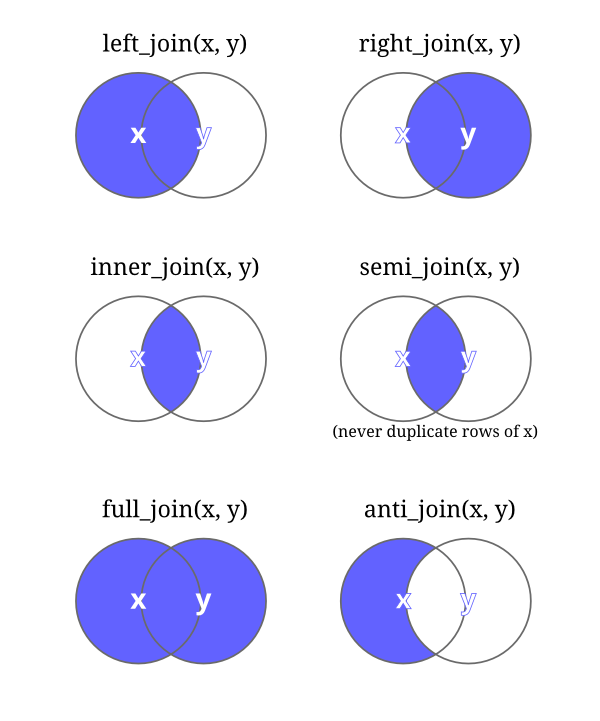

`left_join(x, y)`: Liefert alle Datensätze aus der Haupttabelle (x). Fehlende Werte aus der Nebentabelle (y) werden mit *NA* ergänzt.

Praktische Einsatzmöglichkeit: eine Kundenliste soll mit zusätzlichen Informationen aus einer weiteren Liste (z.B. Adressen) angereichert werden, wobei die Informationen nicht für alle Kunden vorhanden ist.

Mit dem Parameter *by* können die Spalten (*Keys*) vorgegeben werden, über die verknüpft werden soll.

In [38]:
cars_info <- data.frame(
  Anz_Zylinder = c(4, 6, 8),
  Typ = c("Klein", "Mittel", "Groß")
) 

cars_info

dplyr::left_join(df, cars_info, by = "Anz_Zylinder") %>% head(5)

Anz_Zylinder,Typ
<dbl>,<chr>
4,Klein
6,Mittel
8,Groß


,Modell,Reichweite,Anz_Zylinder,Hubraum,PS,Hinterachse,Gewicht,Beschl.,Motorart,Getriebe,Anz_Gänge,Anz_Vergaser,Typ
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<fct>,<dbl>,<dbl>,<chr>
1,Mazda RX4,21.0,6,160,110,3.90,2.620,16.46,V-shaped,Manuell,4,4,Mittel
2,Mazda RX4 Wag,21.0,6,160,110,3.90,2.875,17.02,V-shaped,Manuell,4,4,Mittel
3,Datsun 710,22.8,4,108,93,3.85,2.320,18.61,Straight,Manuell,4,1,Klein
4,Hornet 4 Drive,21.4,6,258,110,3.08,3.215,19.44,Straight,Automatik,3,1,Mittel
5,Hornet Sportabout,18.7,8,360,175,3.15,3.440,17.02,V-shaped,Automatik,3,2,Groß


Die Key-Spalten müssen nicht in beiden Tabellen denselben Namen besitzen.

In [39]:
cars_info <- data.frame(
  Anz_Zyl = c(4, 6, 8),
  Typ = c("Klein", "Mittel", "Groß")
) 

cars_info

dplyr::left_join(df, cars_info, by = c("Anz_Zylinder" = "Anz_Zyl")) %>% head(5)

Anz_Zyl,Typ
<dbl>,<chr>
4,Klein
6,Mittel
8,Groß


,Modell,Reichweite,Anz_Zylinder,Hubraum,PS,Hinterachse,Gewicht,Beschl.,Motorart,Getriebe,Anz_Gänge,Anz_Vergaser,Typ
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<fct>,<dbl>,<dbl>,<chr>
1,Mazda RX4,21.0,6,160,110,3.90,2.620,16.46,V-shaped,Manuell,4,4,Mittel
2,Mazda RX4 Wag,21.0,6,160,110,3.90,2.875,17.02,V-shaped,Manuell,4,4,Mittel
3,Datsun 710,22.8,4,108,93,3.85,2.320,18.61,Straight,Manuell,4,1,Klein
4,Hornet 4 Drive,21.4,6,258,110,3.08,3.215,19.44,Straight,Automatik,3,1,Mittel
5,Hornet Sportabout,18.7,8,360,175,3.15,3.440,17.02,V-shaped,Automatik,3,2,Groß


Eine Verknüpfung ist auch über mehrere Key-Spalten möglich, wobei fehlende Werte mit *NA* ergänzt werden. 

In [40]:
cars_info <- data.frame(
  Anz_Zyl = c(4, 6, 8),
  Anz_Gae = c(3, 4, 5),
  Typ = c("Klein", "Mittel", "Groß")
) 

cars_info

df_left <- dplyr::left_join(df, cars_info, by = c("Anz_Zylinder" = "Anz_Zyl", "Anz_Gänge" = "Anz_Gae"))
head(df_left)
print(paste0("Dimension der neuen Datei: ", nrow(df_left), " Zeilen und ", ncol(df_left), " Spalten."))

Anz_Zyl,Anz_Gae,Typ
<dbl>,<dbl>,<chr>
4,3,Klein
6,4,Mittel
8,5,Groß


,Modell,Reichweite,Anz_Zylinder,Hubraum,PS,Hinterachse,Gewicht,Beschl.,Motorart,Getriebe,Anz_Gänge,Anz_Vergaser,Typ
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<fct>,<dbl>,<dbl>,<chr>
1,Mazda RX4,21.0,6,160,110,3.90,2.620,16.46,V-shaped,Manuell,4,4,Mittel
2,Mazda RX4 Wag,21.0,6,160,110,3.90,2.875,17.02,V-shaped,Manuell,4,4,Mittel
3,Datsun 710,22.8,4,108,93,3.85,2.320,18.61,Straight,Manuell,4,1,NA
4,Hornet 4 Drive,21.4,6,258,110,3.08,3.215,19.44,Straight,Automatik,3,1,NA
5,Hornet Sportabout,18.7,8,360,175,3.15,3.440,17.02,V-shaped,Automatik,3,2,NA
6,Valiant,18.1,6,225,105,2.76,3.460,20.22,Straight,Automatik,3,1,NA


[1] "Dimension der neuen Datei: 32 Zeilen und 13 Spalten."


Sind in beiden Tabellen identische Spaltennamen vorhanden (mit Ausnahme der für die Verknüpfung verwendeten Key-Spalten), kann über den Parameter *suffix* festgelegt werden, welcher Namenszusatz für die Spalten der Haupt- bzw. Nebentabelle verwendet werden soll.

Mit dem Parameter *keep* (Default = NULL) kann gesteuert werden, ob beide Key-Spalten im resultierenden Datensatz erhalten bleiben sollen (keep = TRUE) oder nicht (keep = NULL bzw. keep = FALSE).

Ein wichtiger Aspekt ist, wie die Verknüpfung gehandhabt wird, wenn mehrere Elemente in der Key-Spalte von *y* mit einem Element in der Key-Spalte von *x* übereinstimmen. So kann beispielsweise ein Kunde mehrere Adressen haben. Dieses Verhalten lässt sich über den Parameter *multiple* steuern:
- `all`: Verknüpft alle passenden Elemente in *y* mit den entsprechenden Elementen in *x*.
- `any`: Verknüpft ein (zufällig ausgewähltes) passendes Element in *y* mit dem entsprechenden Element in *x*.
- `first`: Verwendet das erste passende Element in *y*.
- `last`: Verwendet das letzte passende Element in *y*.

Alle in diesem Abschnitt behandelten Join-Varianten bieten mit dem Parameter *relationship* eine Absicherung gegen nicht eindeutige Key-Spalten und helfen, unerwartete Duplikate zu vermeiden. Mit diesem Parameter kann bzw. muss die erwartete Beziehung zwischen den Key-Spalten definiert werden.

Wird beispielsweise eine 1:1-Beziehung erwartet, die Key-Spalten enthalten allerdings Duplikat, enthält der verknüpfte Datensatz mehr Zeilen als vorgesehen. Solche Probleme können durch die Angabe des Parameters frühzeitig erkannt und vermieden werden.

Die möglichen Ausprägungen des Parameters *relationship* sind:
- `one-to-one`: Es wird erwartet, dass jeder Schlüssel in beiden Tabellen höchstens einmal vorkommt (eindeutige IDs). Ein Fehler tritt auf, wenn in einer der beiden Tabellen Duplikate vorhanden sind.
- `one-to-many`: Es wird erwartet, dass die Haupttabelle (x) eindeutige Schlüssel enthält, während die Nebentabelle (y) beliebig viele Duplikate aufweisen darf. Typischer Anwendungsfall ist die Verknüpfung von Stammdaten (Haupttabelle) mit Transaktionen (Nebentabelle).
- `many-to-one`: Es wird erwartet, dass die Nebentabelle (y) eindeutige Schlüssel enthält, während die Haupttabelle (x) Duplikate enthalten darf. Ein typischer Anwendungsfall ist die Verknüpfung von Bestandsdaten (Haupttabelle) mit einer Lookup-Tabelle.
- `many-to-many`: Sowohl die Haupttabelle (x) als auch die Nebentabelle (y) dürfen beliebig viele Duplikate enthalten. Diese Beziehung kann zu einer Vervielfachung der Datensätze führen. Wird diese Beziehung nicht explizit angegeben, aber tritt auf, wird in der Regel eine Warnung ausgegeben.

In [41]:
cars_info_2 <- data.frame(
  Anz_Zyl = c(4, 4, 6, 6, 8),
  Hubraum = c(140, 160, 180, 200, 220)
) 

cars_info_2

df_left <- dplyr::left_join(df, cars_info_2, by = c("Anz_Zylinder" = "Anz_Zyl"), suffix = c("_Orig", "_Neu"), 
                            multiple = "all") 
head(df_left)
print(paste0("Dimension der neuen Datei: ", nrow(df_left), " Zeilen und ", ncol(df_left), " Spalten."))

Anz_Zyl,Hubraum
<dbl>,<dbl>
4,140
4,160
6,180
6,200
8,220


Warning message in dplyr::left_join(df, cars_info_2, by = c(Anz_Zylinder = "Anz_Zyl"), :
"Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 1 of `x` matches multiple rows in `y`.
ℹ Row 3 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship = "many-to-many"` to silence this warning."


,Modell,Reichweite,Anz_Zylinder,Hubraum_Orig,PS,Hinterachse,Gewicht,Beschl.,Motorart,Getriebe,Anz_Gänge,Anz_Vergaser,Hubraum_Neu
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<fct>,<dbl>,<dbl>,<dbl>
1,Mazda RX4,21.0,6,160,110,3.90,2.620,16.46,V-shaped,Manuell,4,4,180
2,Mazda RX4,21.0,6,160,110,3.90,2.620,16.46,V-shaped,Manuell,4,4,200
3,Mazda RX4 Wag,21.0,6,160,110,3.90,2.875,17.02,V-shaped,Manuell,4,4,180
4,Mazda RX4 Wag,21.0,6,160,110,3.90,2.875,17.02,V-shaped,Manuell,4,4,200
5,Datsun 710,22.8,4,108,93,3.85,2.320,18.61,Straight,Manuell,4,1,140
6,Datsun 710,22.8,4,108,93,3.85,2.320,18.61,Straight,Manuell,4,1,160


[1] "Dimension der neuen Datei: 50 Zeilen und 13 Spalten."


In [42]:
df_left <- dplyr::left_join(df, cars_info_2, by = c("Anz_Zylinder" = "Anz_Zyl"), suffix = c("_Orig", "_Neu"), 
                            multiple = "all", 
                            relationship = "many-to-many") 
head(df_left)
print(paste0("Dimension der neuen Datei: ", nrow(df_left), " Zeilen und ", ncol(df_left), " Spalten."))

,Modell,Reichweite,Anz_Zylinder,Hubraum_Orig,PS,Hinterachse,Gewicht,Beschl.,Motorart,Getriebe,Anz_Gänge,Anz_Vergaser,Hubraum_Neu
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<fct>,<dbl>,<dbl>,<dbl>
1,Mazda RX4,21.0,6,160,110,3.90,2.620,16.46,V-shaped,Manuell,4,4,180
2,Mazda RX4,21.0,6,160,110,3.90,2.620,16.46,V-shaped,Manuell,4,4,200
3,Mazda RX4 Wag,21.0,6,160,110,3.90,2.875,17.02,V-shaped,Manuell,4,4,180
4,Mazda RX4 Wag,21.0,6,160,110,3.90,2.875,17.02,V-shaped,Manuell,4,4,200
5,Datsun 710,22.8,4,108,93,3.85,2.320,18.61,Straight,Manuell,4,1,140
6,Datsun 710,22.8,4,108,93,3.85,2.320,18.61,Straight,Manuell,4,1,160


[1] "Dimension der neuen Datei: 50 Zeilen und 13 Spalten."


In [43]:
df_left <- dplyr::left_join(df, cars_info_2, by = c("Anz_Zylinder" = "Anz_Zyl"), suffix = c("_Orig", "_Neu"), 
                            multiple = "first", 
                            relationship = "many-to-many") 
head(df_left)
print(paste0("Dimension der neuen Datei: ", nrow(df_left), " Zeilen und ", ncol(df_left), " Spalten."))

,Modell,Reichweite,Anz_Zylinder,Hubraum_Orig,PS,Hinterachse,Gewicht,Beschl.,Motorart,Getriebe,Anz_Gänge,Anz_Vergaser,Hubraum_Neu
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<fct>,<dbl>,<dbl>,<dbl>
1,Mazda RX4,21.0,6,160,110,3.90,2.620,16.46,V-shaped,Manuell,4,4,180
2,Mazda RX4 Wag,21.0,6,160,110,3.90,2.875,17.02,V-shaped,Manuell,4,4,180
3,Datsun 710,22.8,4,108,93,3.85,2.320,18.61,Straight,Manuell,4,1,140
4,Hornet 4 Drive,21.4,6,258,110,3.08,3.215,19.44,Straight,Automatik,3,1,180
5,Hornet Sportabout,18.7,8,360,175,3.15,3.440,17.02,V-shaped,Automatik,3,2,220
6,Valiant,18.1,6,225,105,2.76,3.460,20.22,Straight,Automatik,3,1,180


[1] "Dimension der neuen Datei: 32 Zeilen und 13 Spalten."


`right_join(x, y)`: Liefert alle Datensätze aus der Nebentabelle (y). Fehlende Werte aus der Haupttabelle (x) werden mit *NA* ergänzt.
Dieser Join wird selten verwendet, ist aber hilfreich, wenn die Nebentabelle die führende Rolle spielt.

Praktische Einsatzmöglichkeit: alle Adressen behalten, auch wenn im Bestand kein Kunde zu einer Adresse gefunden wird.


`inner_join(x, y)`: Liefert alle Datensätze, die in Haupt- (x) und Nebentabelle (y) vorhanden sind.

Praktische Einsatzmöglichkeit: wird verwendet, wenn nur vollständig übereinstimmende Datensätze analysiert werden sollen, z.B. nur Kunden, für die auch eine Adresse bekannt ist.

`full_join(x, y)`: Liefert alle Datensätze, die entweder in Haupt- (x) oder Nebentabelle (y) oder in beiden Tabellen vorhanden sind. Fehlende Werte werden mit *NA* ergänzt.

Praktische Einsatzmöglichkeit: wird verwendet, wenn alle Datensätze aus verschiedenen Quellen zusammengeführt werden sollen, z.B. Kunden- und Adressenliste.

`semi_join(x, y)`: Ist ein filternder Join und liefert alle Datensätze aus der Haupttabelle (x), die in der Nebentabelle (y) vorhanden sind. Es werden keine Duplikate oder zusätzliche Spalten erzeugt.

Praktische Einsatzmöglichkeit: wird verwendet, um eine relevante Teilmenge aus der Haupttabelle zu filtern, z.B. Kunden, die in der Adressenliste vorkommen.

In [44]:
cars_info_part <- data.frame(
  Anz_Zyl = c(4, 6),
  Typ = c("Klein", "Mittel")
) 

cars_info_part

df_semi <- dplyr::semi_join(df, cars_info_part, by = c("Anz_Zylinder" = "Anz_Zyl")) 
head(df_semi)
print(paste0("Dimension der neuen Datei: ", nrow(df_semi), " Zeilen und ", ncol(df_semi), " Spalten."))

Anz_Zyl,Typ
<dbl>,<chr>
4,Klein
6,Mittel


,Modell,Reichweite,Anz_Zylinder,Hubraum,PS,Hinterachse,Gewicht,Beschl.,Motorart,Getriebe,Anz_Gänge,Anz_Vergaser
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<fct>,<dbl>,<dbl>
1,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,V-shaped,Manuell,4,4
2,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,V-shaped,Manuell,4,4
3,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,Straight,Manuell,4,1
4,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,Straight,Automatik,3,1
5,Valiant,18.1,6,225.0,105,2.76,3.460,20.22,Straight,Automatik,3,1
6,Merc 240D,24.4,4,146.7,62,3.69,3.190,20.00,Straight,Automatik,4,2


[1] "Dimension der neuen Datei: 18 Zeilen und 12 Spalten."


**Bemerkung:** Selbstverständlich kann die Filterung auch mit der oben angeführten Funktion *filter()* durchgeführt werden. Allerdings müssen in diesem Fall die einzelnen Key-Spalten einzeln abgefragt werden, wodurch die Abfrage bzw. der Code unübersichtlich werden kann.

Ein `semi_join()` wird häufig in einer Kette von Joins verwendet, in der eine Filterung benötigt wird. In diesem Fall ist die Lesbarkeit des Codes mit einem `semi_join()` deutlich höher, da nicht alle Filterbedingungen explizit angeführt werden müssen, sondern nur die Namen der Key-Spalten.


In [45]:
df_semi2 <- df %>% dplyr::filter(Anz_Zylinder %in% unique(cars_info_part$Anz_Zyl)) 

head(df_semi2)
print(paste0("Dimension der neuen Datei: ", nrow(df_semi2), " Zeilen und ", ncol(df_semi2), " Spalten."))

,Modell,Reichweite,Anz_Zylinder,Hubraum,PS,Hinterachse,Gewicht,Beschl.,Motorart,Getriebe,Anz_Gänge,Anz_Vergaser
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<fct>,<dbl>,<dbl>
1,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,V-shaped,Manuell,4,4
2,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,V-shaped,Manuell,4,4
3,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,Straight,Manuell,4,1
4,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,Straight,Automatik,3,1
5,Valiant,18.1,6,225.0,105,2.76,3.460,20.22,Straight,Automatik,3,1
6,Merc 240D,24.4,4,146.7,62,3.69,3.190,20.00,Straight,Automatik,4,2


[1] "Dimension der neuen Datei: 18 Zeilen und 12 Spalten."


`anti_join(x, y)`: Ist ein filternder Join und liefert alle Datensätze aus der Haupttabelle (x), die nicht in der Nebentabelle (y) vorhanden sind. Es werden keine Duplikate oder zusätzliche Spalten erzeugt.

Praktische Einsatzmöglichkeit: wird zur Fehlersuche und Datenqualitätsicherung verwendet, um alle Einträge in der Haupttabelle zu finden, die keinen Eintrag in der Nebentabelle haben, z.B. Kunden, für die keine Eintrag in der Adressenliste vorhanden ist.

In [46]:
df_anti <- dplyr::anti_join(df, cars_info_part, by = c("Anz_Zylinder" = "Anz_Zyl")) 
head(df_anti)
print(paste0("Dimension der neuen Datei: ", nrow(df_anti), " Zeilen und ", ncol(df_anti), " Spalten."))

,Modell,Reichweite,Anz_Zylinder,Hubraum,PS,Hinterachse,Gewicht,Beschl.,Motorart,Getriebe,Anz_Gänge,Anz_Vergaser
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<fct>,<dbl>,<dbl>
1,Hornet Sportabout,18.7,8,360.0,175,3.15,3.44,17.02,V-shaped,Automatik,3,2
2,Duster 360,14.3,8,360.0,245,3.21,3.57,15.84,V-shaped,Automatik,3,4
3,Merc 450SE,16.4,8,275.8,180,3.07,4.07,17.40,V-shaped,Automatik,3,3
4,Merc 450SL,17.3,8,275.8,180,3.07,3.73,17.60,V-shaped,Automatik,3,3
5,Merc 450SLC,15.2,8,275.8,180,3.07,3.78,18.00,V-shaped,Automatik,3,3
6,Cadillac Fleetwood,10.4,8,472.0,205,2.93,5.25,17.98,V-shaped,Automatik,3,4


[1] "Dimension der neuen Datei: 14 Zeilen und 12 Spalten."


**Bemerkung:** Selbstverständlich kann die Filterung auch hier mit der Funktion *filter()* durchgeführt werden.

In [47]:
df_semi2 <- df %>% dplyr::filter(!(Anz_Zylinder %in% unique(cars_info_part$Anz_Zyl)))

head(df_semi2)
print(paste0("Dimension der neuen Datei: ", nrow(df_semi2), " Zeilen und ", ncol(df_semi2), " Spalten."))

,Modell,Reichweite,Anz_Zylinder,Hubraum,PS,Hinterachse,Gewicht,Beschl.,Motorart,Getriebe,Anz_Gänge,Anz_Vergaser
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<fct>,<dbl>,<dbl>
1,Hornet Sportabout,18.7,8,360.0,175,3.15,3.44,17.02,V-shaped,Automatik,3,2
2,Duster 360,14.3,8,360.0,245,3.21,3.57,15.84,V-shaped,Automatik,3,4
3,Merc 450SE,16.4,8,275.8,180,3.07,4.07,17.40,V-shaped,Automatik,3,3
4,Merc 450SL,17.3,8,275.8,180,3.07,3.73,17.60,V-shaped,Automatik,3,3
5,Merc 450SLC,15.2,8,275.8,180,3.07,3.78,18.00,V-shaped,Automatik,3,3
6,Cadillac Fleetwood,10.4,8,472.0,205,2.93,5.25,17.98,V-shaped,Automatik,3,4


[1] "Dimension der neuen Datei: 14 Zeilen und 12 Spalten."


## Praktische Übungen zu `dplyr`

### Übung 1: Filtern und Auswählen

Erstelle Sie aus `df` einen neuen Datensatz, der nur Fahrzeuge mit 4 Zylinder (`Anz_Zylinder`) und einer Reichweite (`Reichweite`) über 25 enthält. Der Datensatz soll anschließend auf die Spalten `Modell`, `Reichweite`, `PS` und `Getriebe` eingeschränkt werden.

In [48]:
# Übung 1
# Tipp: Verwende dplyr::filter() und dplyr::select().

uebung1 <- df %>%
  dplyr::filter(Anz_Zylinder == 4, Reichweite > 25) %>%
  dplyr::select(Modell, Reichweite, PS, Getriebe)
uebung1

Modell,Reichweite,PS,Getriebe
<chr>,<dbl>,<dbl>,<fct>
Fiat 128,32.4,66,Manuell
Honda Civic,30.4,52,Manuell
Toyota Corolla,33.9,65,Manuell
Fiat X1-9,27.3,66,Manuell
Porsche 914-2,26.0,91,Manuell
Lotus Europa,30.4,113,Manuell


### Übung 2: Neue Variablen mit `mutate()`

Erzeugen Sie in `df` die beiden neuen Variablen `Leistung_kW` (Umrechnung von PS in kW mit dem Faktor 0.7355) und `Gewicht_kg` (Umrechnung von 1000 lbs in kg mit dem Faktor 453.592 / 1000). Geben Sie danach die ersten 3 Zeilen aus.

In [49]:
# Übung 2
# Tipp: Beide neuen Variablen können in einem einzigen mutate()-Aufruf erstellt werden.

uebung2 <- df %>%
  dplyr::mutate(
    Leistung_kW = PS * 0.7355,
    Gewicht_kg = Gewicht * 453.592 / 1000
  ) %>%
  head(n = 3)
uebung2

,Modell,Reichweite,Anz_Zylinder,Hubraum,PS,Hinterachse,Gewicht,Beschl.,Motorart,Getriebe,Anz_Gänge,Anz_Vergaser,Leistung_kW,Gewicht_kg
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>
1,Mazda RX4,21.0,6,160,110,3.90,2.620,16.46,V-shaped,Manuell,4,4,80.9050,1.188411
2,Mazda RX4 Wag,21.0,6,160,110,3.90,2.875,17.02,V-shaped,Manuell,4,4,80.9050,1.304077
3,Datsun 710,22.8,4,108,93,3.85,2.320,18.61,Straight,Manuell,4,1,68.4015,1.052333


### Übung 3: Gruppieren und Zusammenfassen

Bestimmen Sie für jedes Getriebe (`Getriebe`) die Anzahl der Fahrzeuge, den durchschnittlichen PS-Wert und die mittlere Reichweite. Sortiere das Ergebnis anschließend absteigend nach der mittleren Reichweite.

In [50]:
# Übung 3
# Tipp: Nutze group_by(), summarise() und arrange().

uebung3 <- df %>%
  dplyr::group_by(Getriebe) %>%
  dplyr::summarise(
    Anzahl_Fahrzeuge = n(),
    Durchschnitt_PS = mean(PS),
    Mittlere_Reichweite = mean(Reichweite),
    .groups = "drop"
  ) %>%
  dplyr::arrange(desc(Mittlere_Reichweite))
uebung3

Getriebe,Anzahl_Fahrzeuge,Durchschnitt_PS,Mittlere_Reichweite
<fct>,<int>,<dbl>,<dbl>
Manuell,13,126.8462,24.39231
Automatik,19,160.2632,17.14737


### Übung 4: Join mit Zusatzinformationen

Erzeugen Sie zunächst folgenden Lookup-Datensatz

```r
Verbrauchsklasse <- tibble(
  Anz_Zylinder = c(4, 6, 8),
  Klasse = c("sparsam", "mittel", "leistungsstark")
)
```

als Nebentabelle und verknüpfen Sie ihn mit einem `left_join()` mit `df` über `Anz_Zylinder`. Zähle Sie anschließend, wie viele Fahrzeuge je Klasse vorhanden sind.

In [51]:
# Übung 4
# Tipp: Erzeuge zuerst den Lookup-Datensatz und verwende danach left_join() und count().

Verbrauchsklasse <- tibble(
  Anz_Zylinder = c(4, 6, 8),
  Klasse = c("sparsam", "mittel", "leistungsstark")
)

uebung4 <- df %>%
  dplyr::left_join(Verbrauchsklasse, by = "Anz_Zylinder") %>%
  dplyr::count(Klasse)
uebung4

Klasse,n
<chr>,<int>
leistungsstark,14
mittel,7
sparsam,11


## Funktionen im Paket `tidyr`

Das Paket `tidyr` hilft, Daten in eine saubere und strukturierte Form zu bringen. Ziel ist es, sogenannte „tidy data“ zu erzeugen, bei denen jede Variable eine Spalte, jede Beobachtung eine Zeile und jeder Wert eine einzelne Zelle ist.

In diesem Abschnitt wird der folgende Datensatz als Testdatensatz verwendet:


In [52]:
df_pivot <- tibble(
  Variable = c("Pr", "Le", "Ko"),
  Beschreibung = c("Prämie", "Leistung", "Kosten"),
  Jahr_2023 = c(100, 70, 20),
  Jahr_2024 = c(110, 75, 25),
  Jahr_2025 = c(120, 80, 30)    
)

df_pivot

Variable,Beschreibung,Jahr_2023,Jahr_2024,Jahr_2025
<chr>,<chr>,<dbl>,<dbl>,<dbl>
Pr,Prämie,100,110,120
Le,Leistung,70,75,80
Ko,Kosten,20,25,30


Die wichtigsten Funktionen aus dem Paket **tidyr** für die Datenumformung (*df_pivot* ist dabei immer der aktuelle Datensatz) sind:

| Funktion         | Zweck                        | Beispiel                                                          |
| ---------------- | ----------------------------- | -----------------------------------------------------------------|
| `pivot_longer()` | Breit → Lang                  | `pivot_longer(df_pivot, cols = Jahr_2023:Jahr_2025)`             |
| `pivot_wider()`  | Lang → Breit                  | `pivot_wider(df_pivot, names_from = Jahr, values_from = Werte)`  |
| `separate()`     | Spalte splitten               | `separate(df_pivot, name, c("X","Y"))`                           |
| `unite()`        | Spalten zusammenführen        | `unite(df_pivot, Neu, X, Y)`                                     |
| `drop_na()`      | Zeilen mit NA werden gelöscht | `drop_na(df_pivot, Spalte_1, Spalte_2)`                          |
| `replace_na()`   | NAs ersetzen                  | `replace_na(df_pivot, list(Jahr=0))`                             |


`pivot_longer()`: Die Funktion wird verwendet, um Daten von einem "breiten" Format in ein "langes" Format zu transformieren. 

Der typische Anwendungsfall ist, wenn mehrere Spalten im ursprünglichen Datensatz Werte derselben Variable darstellen, z.B. Prämien der einzelnen Jahre. Die Daten lassen sich nach der Transformation leichter analysieren und visualisieren (siehe 4. Teil der Seminarreihe zum Theme Visualisierung).

In [53]:
df_longer <- tidyr::pivot_longer(df_pivot, cols = Jahr_2023:Jahr_2025, names_to = "Jahr", values_to = "Werte")
df_longer

Variable,Beschreibung,Jahr,Werte
<chr>,<chr>,<chr>,<dbl>
Pr,Prämie,Jahr_2023,100
Pr,Prämie,Jahr_2024,110
Pr,Prämie,Jahr_2025,120
Le,Leistung,Jahr_2023,70
Le,Leistung,Jahr_2024,75
Le,Leistung,Jahr_2025,80
Ko,Kosten,Jahr_2023,20
Ko,Kosten,Jahr_2024,25
Ko,Kosten,Jahr_2025,30


`pivot_wider()`: Die Funktion ist das Gegenstück zur obigen Funktion und wird verwendet, um Daten von einem "langen" Format in ein "breites" Format zu transformieren. 

Der typische Anwendungsfall ist, wenn Werte als eigene Spalte für eine übersichtliche Darstellung in Berichten oder Tabellen benötigt werden.

In [54]:
tidyr::pivot_wider(df_longer, names_from = Jahr, values_from = Werte)

Variable,Beschreibung,Jahr_2023,Jahr_2024,Jahr_2025
<chr>,<chr>,<dbl>,<dbl>,<dbl>
Pr,Prämie,100,110,120
Le,Leistung,70,75,80
Ko,Kosten,20,25,30


`separate()`: Teilt eine Spalte anhand eines Trennzeichens in mehrere Spalten auf. 

Der typische Anwendungsfall ist, wenn mehrere Informationen in einer Spalte gespeichert sind und getrennt benötigt werden, z.B. der Name des VN soll in eine Spalte mit Vornamen und eine Spalte mit Nachnamen aufgeteilt werden.

In [55]:
df_sep <- tidyr::pivot_longer(df_pivot, cols = Jahr_2023:Jahr_2025, names_to = "Jahr_tmp", values_to = "Werte") %>%
  tidyr::separate(Jahr_tmp, c("Text", "Jahr"))
df_sep

Variable,Beschreibung,Text,Jahr,Werte
<chr>,<chr>,<chr>,<chr>,<dbl>
Pr,Prämie,Jahr,2023,100
Pr,Prämie,Jahr,2024,110
Pr,Prämie,Jahr,2025,120
Le,Leistung,Jahr,2023,70
Le,Leistung,Jahr,2024,75
Le,Leistung,Jahr,2025,80
Ko,Kosten,Jahr,2023,20
Ko,Kosten,Jahr,2024,25
Ko,Kosten,Jahr,2025,30


In [56]:
df_sep <- tidyr::pivot_longer(df_pivot, cols = Jahr_2023:Jahr_2025, names_to = "Jahr_tmp", values_to = "Werte") %>%
  tidyr::separate_wider_delim(cols = Jahr_tmp, delim = "_", names = c("Text", "Jahr"))
df_sep

Variable,Beschreibung,Text,Jahr,Werte
<chr>,<chr>,<chr>,<chr>,<dbl>
Pr,Prämie,Jahr,2023,100
Pr,Prämie,Jahr,2024,110
Pr,Prämie,Jahr,2025,120
Le,Leistung,Jahr,2023,70
Le,Leistung,Jahr,2024,75
Le,Leistung,Jahr,2025,80
Ko,Kosten,Jahr,2023,20
Ko,Kosten,Jahr,2024,25
Ko,Kosten,Jahr,2025,30


`unite()`: Die Funktion ist das Gegenstück zur obigen Funktion und wird verwendet, mehrere Spalten zu einer Spalte zu kombinieren. 

Der typische Anwendungsfall ist, wenn mehrere Informationen in einer Spalte zusammengefasst werden sollen, z. B. eine einzige Namensspalte statt getrennt nach Vor- und Nachname. 

In [57]:
tidyr::unite(df_sep, col = "Test", Text, Jahr, sep = "*")

Variable,Beschreibung,Test,Werte
<chr>,<chr>,<chr>,<dbl>
Pr,Prämie,Jahr*2023,100
Pr,Prämie,Jahr*2024,110
Pr,Prämie,Jahr*2025,120
Le,Leistung,Jahr*2023,70
Le,Leistung,Jahr*2024,75
Le,Leistung,Jahr*2025,80
Ko,Kosten,Jahr*2023,20
Ko,Kosten,Jahr*2024,25
Ko,Kosten,Jahr*2025,30


`replace_na()`: Mit dieser Funktion werden fehlende Werte (*NA*) in den Daten durch sinnvolle (vorgegebene) Werte ersetzt. Der typische Anwendungsfall ist, wenn die fehlenden Werte Analysen oder Visualisierungen stören.

In [58]:
df_na <- tidyr::pivot_wider(df_longer[c(1:4,6:8),], names_from = Jahr, values_from = Werte)
df_na

Variable,Beschreibung,Jahr_2023,Jahr_2024,Jahr_2025
<chr>,<chr>,<dbl>,<dbl>,<dbl>
Pr,Prämie,100,110,120
Le,Leistung,70,NA,80
Ko,Kosten,20,25,NA


Im Datensatz fehlen die Werte für die Leistung im Jahr 2024 und die Kosten im Jahr 2025.

In [59]:
tidyr::replace_na(df_na, list(Jahr_2024 = -1, Jahr_2025 = 0))

Variable,Beschreibung,Jahr_2023,Jahr_2024,Jahr_2025
<chr>,<chr>,<dbl>,<dbl>,<dbl>
Pr,Prämie,100,110,120
Le,Leistung,70,-1,80
Ko,Kosten,20,25,0


**Hinweis**: Die Funktion *pivot_wider* enthält mit dem Parameter *values_fill* direkt die Möglichkeit, fehlende Werte mit einem vorgegeben Wert ersetzen zu lassen.

In [60]:
tidyr::pivot_wider(df_longer[c(1:4,6:8),], names_from = Jahr, values_from = Werte, values_fill = -1)

Variable,Beschreibung,Jahr_2023,Jahr_2024,Jahr_2025
<chr>,<chr>,<dbl>,<dbl>,<dbl>
Pr,Prämie,100,110,120
Le,Leistung,70,-1,80
Ko,Kosten,20,25,-1


`drop_na()`: Mit dieser Funktion können alle Datensätze gelöscht werden, die fehlende Werte (*NA*) enthalten.

In [61]:
tidyr::drop_na(df_na, Jahr_2024)

Variable,Beschreibung,Jahr_2023,Jahr_2024,Jahr_2025
<chr>,<chr>,<dbl>,<dbl>,<dbl>
Pr,Prämie,100,110,120
Ko,Kosten,20,25,NA


In [62]:
tidyr::drop_na(df_na)

Variable,Beschreibung,Jahr_2023,Jahr_2024,Jahr_2025
<chr>,<chr>,<dbl>,<dbl>,<dbl>
Pr,Prämie,100,110,120


## Praktische Übungen zu `tidyr`

### Übung 5: Von breit nach lang

Wandlen Sie `df_pivot` mit `pivot_longer()` in ein langes Format um. Die Jahres-Spalten sollen in einer neuen Spalte `Jahr` stehen, die Werte in einer Spalte `Wert`.

In [63]:
# Übung 5
# Tipp: Verwende die Spalten Jahr_2023 bis Jahr_2025.

uebung5 <- df_pivot %>%
  tidyr::pivot_longer(cols = Jahr_2023:Jahr_2025, names_to = "Jahr", values_to = "Wert")
uebung5

Variable,Beschreibung,Jahr,Wert
<chr>,<chr>,<chr>,<dbl>
Pr,Prämie,Jahr_2023,100
Pr,Prämie,Jahr_2024,110
Pr,Prämie,Jahr_2025,120
Le,Leistung,Jahr_2023,70
Le,Leistung,Jahr_2024,75
Le,Leistung,Jahr_2025,80
Ko,Kosten,Jahr_2023,20
Ko,Kosten,Jahr_2024,25
Ko,Kosten,Jahr_2025,30


### Übung 6: Jahr aus dem Spaltennamen trennen

Bauen Sie auf dem Ergebnis aus Übung 5 auf und trennen Sie die Spalte `Jahr` so auf, dass am Ende nur noch die Jahreszahl in einer Spalte `Jahr_num` steht. Die Vorsilbe `Jahr_` soll entfernt werden.

In [64]:
# Übung 6
# Tipp: Das geht z. B. mit separate_wider_delim() oder mit stringr::str_remove().

uebung6 <- uebung5 %>%
  tidyr::separate_wider_delim(cols = Jahr, delim = "_", names = c("Text", "Jahr")) %>%
  dplyr::rename(Jahr_num = Jahr)
uebung6 

Variable,Beschreibung,Text,Jahr_num,Wert
<chr>,<chr>,<chr>,<chr>,<dbl>
Pr,Prämie,Jahr,2023,100
Pr,Prämie,Jahr,2024,110
Pr,Prämie,Jahr,2025,120
Le,Leistung,Jahr,2023,70
Le,Leistung,Jahr,2024,75
Le,Leistung,Jahr,2025,80
Ko,Kosten,Jahr,2023,20
Ko,Kosten,Jahr,2024,25
Ko,Kosten,Jahr,2025,30


### Übung 7: Spalten zusammenführen

Erstellen Sie aus `df_sep` wieder eine gemeinsame Spalte `Jahr_Code`, in der `Text` und `Jahr` mit einem Bindestrich verbunden werden. Geben Sie danach nur die Spalten `Variable`, `Jahr_Code` und `Werte` aus.

In [65]:
# Übung 7
# Tipp: Verwende unite() und select().

uebung7 <- uebung6 %>%
  tidyr::unite("Jahr_Code", Text, Jahr_num, sep = "-") %>%
  dplyr::select(Variable, Jahr_Code, Wert)
uebung7

Variable,Jahr_Code,Wert
<chr>,<chr>,<dbl>
Pr,Jahr-2023,100
Pr,Jahr-2024,110
Pr,Jahr-2025,120
Le,Jahr-2023,70
Le,Jahr-2024,75
Le,Jahr-2025,80
Ko,Jahr-2023,20
Ko,Jahr-2024,25
Ko,Jahr-2025,30


## Funktionen im Paket `stringr`

Das Paket `stringr` bietet eine konsistente und leicht lesbare Sammlung von Funktionen zur Arbeit mit Texten bzw. Strings. Alle Funktionen folgen dem einheitlichen Schema `str_*`.


Die wichtigsten Funktionen aus dem Paket **stringr** für die Arbeit mit Strings sind:

| Funktion                                                            | Zweck                                                       |
| ------------------------------------------------------------------- | ----------------------------------------------------------- |
| `str_detect(String, Muster)`                                        | Prüft, ob ein Muster im String vorkommt                     |
| `str_count(String, Muster)`                                         | Zählt, wie oft ein Muster vorkommt                          |
| `str_replace(String, Alt, Neu), str_replace_all(String, Alt, Neu)`  | Ersetzt das erste bzw. alle Vorkommen eines Musters *Alt*   |
| `str_extract(String, Muster), str_extract_all(String, Muster)`      | Extrahiert das erste bzw. alle Vorkommen eines Musters      |
| `str_remove(String, Muster), str_remove_all(String, Muster)`        | Löscht das erste bzw. alle Vorkommen eines Musters          |
| `str_c(Strings, sep, collapse)`                                     | Fügt Strings zusammen                                       |
| `str_trim(String, side)`                                            | Entfernt Leerzeichen am Anfang und am Ende                  |
| `str_squish(String)`                                                | Entfernt überflüssige Leerzeichen (auch in der Mitte)       |
| `str_length(String)`                                                | Anzahl der Zeichen                                          |
| `str_sub(String, start, end)`                                       | Teilstring von Position *start* bis *end* extrahieren       |
| `str_to_lower(String), str_to_upper(String)`                        | Der gesamte Text in Klein- bzw. Großbuchstaben              |

Das Paket *stringr* arbeitet stark mit *regulären Ausdrücken (Regex)*. Bevor näher auf die oben angeführten Funktionen eingegangen wird, erfolgt eine kurze Einführung in Regex.

Die Grundidee von Regex ist die Beschreibung von Mustern in Texten, z.B.  
- enthält eine Zahl
- beginnt mit A
- hat genau 5 Zeichen
Mit Regex werden keine vorgegebenen Strings, sondern Strukturen im Text gesucht.

**Achtung**: Regex ist standardmäßig case-sensitive!

*Zeichenklassen* von Regex: 

| Regex | Bedeutung          | Beispiel                                      | 
| ----- | ------------------ | --------------------------------------------- | 
| `.`   | Wildcard (irgendein Zeichen)  | `a.c` entspricht `abc`, `a1c`, ... |
| `\\d` | Ziffer (0–9)       | `"abc123"` findet `1`                         |
| `\\w` | Buchstabe/Ziffer/_ | `"abc_1"` findet `w`                          | 
| `\\s` | Leerzeichen        | `"a b"`                                       |

Gegenteile: `\\D` (keine Zahl), `\\W` (kein Wort) bzw. `\\S` (kein Leerzeichen).

*Zeichenmengen* in Regex:

| Regex   | Bedeutung       |
| ------- | --------------- |
| `[abc]` | a oder b oder c |
| `[a-z]` | Kleinbuchstaben |
| `[A-Z]` | Großbuchstaben  |
| `[0-9]` | Zahlen          |

Die Negation erfolgt durch `^`, z.B. `[^0-9]` (alles außer Zahlen).

Wiederholungen (Quantifier)

| Regex   | Bedeutung        |
| ------- | ---------------- |
| `*`     | 0 oder mehr      |
| `+`     | 1 oder mehr      |
| `?`     | 0 oder 1         |
| `{n}`   | genau n          |
| `{n,}`  | mindestens n     |
| `{n,m}` | zwischen n und m |

Beispiel: `\\d+` bedeutet *ein oder mehrere Zahlen*.

Positionen im Text

| Regex | Bedeutung                                        |
| ----- | ------------------------------------------------ |
| `^`   | Anfang                                           |
| `$`   | Ende                                             |
| `\\b` | Wortgrenze - wird zur Positionsprüfung verwendet | 

Beispiele: `"^H"` (beginnt mit H), `ab$` (endet mit ab).

`str_detect(String, Muster)` prüft, ob das Muster im String vorkommt.

In [66]:
stringr::str_detect("Der ursprüngliche String steht an erster Position, der gesuchte String an zweiter Position.", "String")

[1] TRUE

Alle Funktionen im Paket *stringr* sind vektorisiert, d. h. die Suche in mehreren Strings gleichzeitig ist möglich.

In [67]:
stringr::str_detect(df$Modell, "Mazda")

[1]  TRUE  TRUE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[13] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE
[25] FALSE FALSE FALSE FALSE FALSE FALSE FALSE FALSE

`str_count(String, Muster)` zählt, wie oft das Muster im String vorkommt.

In [68]:
stringr::str_count("Der ursprüngliche String steht an erster Position, der gesuchte String an zweiter Position.", "er")

[1] 5

`str_replace(String, Muster_alt, Muster_neu)` bzw. `str_replace_all(String, Muster_alt, Muster_neu)` ersetzt das erste bzw. alle Vorkommen von *Muster_alt* durch *Muster_neu*.

In [69]:
stringr::str_replace("Der-String-steht-an-erster-Position.", "-", "_")
stringr::str_replace_all("Der-String-steht-an-erster-Position.", "-", "_")

[1] "Der_String-steht-an-erster-Position."

[1] "Der_String_steht_an_erster_Position."

`str_extract(String, Muster)` bzw. `str_extract_all(String, Muster)` extrahiert das erste bzw. alle Vorkommen von *Muster* im String. Diese Funktion wird häufig mit Regex-Ausdrücken verwendet.

In [70]:
stringr::str_extract("Im Bericht sind die Werte aus den Jahren 2023, 2024 und 2025 enthalten.", "\\d+")     # Extrahiert die erste Zahl im Text
stringr::str_extract_all("Im Bericht sind die Werte aus den Jahren 2023, 2024 und 2025 enthalten.", "\\d+") # Extrahiert alle Zahlen im Text

[1] "2023"

[[1]]
[1] "2023" "2024" "2025"

Soll eine Zahl mit genau einer vorgegebenen Anzahl von Zifferen aus einem String extrahiert werden, reicht der folgende Regex-Ausdruck nicht aus, da auch Teile von längeren Zahlen gefunden werden (siehe *123* aus der Zahlenfolge *1234*)

In [71]:
stringr::str_extract_all("Zwei Ziffern 12, drei Zifferen 123, vier Ziffern 1234, drei Ziffern 456.", "\\d{3}") 

[[1]]
[1] "123" "123" "456"

Eine Abgrenzung der gewünschten Form (*genau drei Zifferen*) kann mit dem Kürzel `\\b` (Wortgrenze) erreicht werden.

In [72]:
stringr::str_extract_all("Zwei Ziffern 12, drei Zifferen 123, vier Ziffern 1234, drei Ziffern 456.", "\\b\\d{3}\\b") 

[[1]]
[1] "123" "456"

`str_remove(String, Muster)` bzw. `str_remove_all(String, Muster)` löscht das erste bzw. alle Vorkommen von *Muster* im String.

In [73]:
stringr::str_remove("Im Bericht sind die Werte aus den Jahren 2023, 2024 und 2025 enthalten.", "\\d+")     # Extrahiert die erste Zahl im Text
stringr::str_remove_all("Im Bericht sind die Werte aus den Jahren 2023, 2024 und 2025 enthalten.", "\\d+") # Extrahiert alle Zahlen im Text

[1] "Im Bericht sind die Werte aus den Jahren , 2024 und 2025 enthalten."

[1] "Im Bericht sind die Werte aus den Jahren ,  und  enthalten."

`str_c(Strings, sep = "-", collapse = " ")` fügt die in `Strings` enthaltenen Zeichenketten zusammen. Die Funktion hat zwei Parameter *sep* und *collapse*:  
- `sep`: Kombiniert Vektoren elementweise parallel. Das Ergebnis bleibt ein Vektor.
- `collapse`: Kombiniert die Elemente eines Vektors zu einem einzigen String.


In [74]:
stringr::str_c(c("A", "B"), c("1", "2"), sep = "-")

[1] "A-1" "B-2"

In [75]:
stringr::str_c(c("A", "B", "C"), collapse = ", ")

[1] "A, B, C"

In [76]:
stringr::str_c(c("A", "B"), c("1", "2"), sep = "-", collapse = ", ")

[1] "A-1, B-2"

`str_trim(String, side = c("both", "left", "right"))` entfernt Leerzeichen am Beginn und/oder am Ende eines Strings.

In [77]:
stringr::str_trim("    Die    Leerzeichen zu Beginn und am     Ende werden entfernt     ")

[1] "Die    Leerzeichen zu Beginn und am     Ende werden entfernt"

`str_squish(String)` löscht alle überflüssigen Leerzeichen im String.

In [78]:
stringr::str_squish("    Überflüssige    Leerzeichen    werden entfernt   (auch in der     Mitte)    ")

[1] "Überflüssige Leerzeichen werden entfernt (auch in der Mitte)"

`str_length(String)` zählt die Anzahl der Zeichen im String.

In [79]:
stringr::str_length("Zählt die Anzahl der Zeichen im String")

[1] 38

`str_sub(String, start, end)` extrahiert einen Teilstring von der Position *start* bis *end*.

In [80]:
stringr::str_sub("Extrahiert einen Teilstring von der Position start bis end.", start = 18, end = 27)

[1] "Teilstring"

## Praktische Übungen zu `stringr`

Für die nächsten beiden Aufgaben wird der folgende Textvektor verwendet.

In [81]:
texte_uebung <- c(
  "  Kunde A: Rechnung 2024 offen  ",
  "Kunde_B - bezahlt am 15.03.2025",
  "Support-Fall 17 wurde eskaliert",
  "kontakt@beispiel.at",
  "PLZ 4020 Linz"
)

texte_uebung

[1] "  Kunde A: Rechnung 2024 offen  " "Kunde_B - bezahlt am 15.03.2025" 
[3] "Support-Fall 17 wurde eskaliert"  "kontakt@beispiel.at"             
[5] "PLZ 4020 Linz"

### Übung 8: Muster erkennen

Prüfen Sie mit `str_detect()`, welche Einträge in `texte_uebung` eine Zahl enthalten.

In [82]:
# Übung 8
# Tipp: Verwende einen Regex-Ausdruck für Ziffern.

uebung8 <- stringr::str_detect(texte_uebung, "\\d")
uebung8

[1]  TRUE  TRUE  TRUE FALSE  TRUE

### Übung 9: Text bereinigen und Informationen extrahieren

Lösen Sie die folgenden zwei Teilaufgaben:

1. Bereinigen Sie `texte_uebung`, indem führende und nachgestellte Leerzeichen entfernt werden.
2. Extrahieren Sie aus `texte_uebung` alle vorkommenden Zahlenfolgen (z. B. Jahr, Tag, Monat, Fallnummer, Postleitzahl).

Speichern Sie die beide Ergebnisse in getrennten Objekten.

In [83]:
# Übung 9
# Tipp: Kombiniere str_trim() bzw. str_squish() mit str_extract_all().

uebung9_1 <- stringr::str_trim(texte_uebung)
uebung9_2 <- stringr::str_extract_all(texte_uebung, "\\d+")

uebung9_1
uebung9_2

[1] "Kunde A: Rechnung 2024 offen"    "Kunde_B - bezahlt am 15.03.2025"
[3] "Support-Fall 17 wurde eskaliert" "kontakt@beispiel.at"            
[5] "PLZ 4020 Linz"

[[1]]
[1] "2024"

[[2]]
[1] "15"   "03"   "2025"

[[3]]
[1] "17"

[[4]]
character(0)

[[5]]
[1] "4020"

## Literatur- und Praxistipps

1. Eine sehr gute Übersicht über die Analyse-Möglichkeiten in *R* ist auf der Seite https://r4ds.hadley.nz/ zu finden.
